# Importar librerías


In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import unicodedata
import warnings

warnings.filterwarnings("ignore")

# EDA


Los Datos fueron generados a través de un sistema de simulación, automatizado para que el código quede mas limpio. Para más información revisar `data-science\src\generar_dataset_transacciones.py`


In [2]:
df_gastos = pd.read_csv("../data/raw/transacciones_simuladas.csv")
df_gastos

,descripcion,categoria,monto
0,*supermercado*,Alimentación,647.41
1,COMPRA EN SUPERMERCADO,Alimentación,498.99
2,*supermercado*,Alimentación,384.37
3,*supermercado*,Alimentación,93.56
4,COMPRA EN SUPERMERCADO,Alimentación,300.28
...,...,...,...
1705,DOMESTIKA,Educación,1995.49
1706,compra dermatologo,Salud,1445.62
1707,FARMACIAS DEL AHORRO,Salud,668.42
1708,Zoologico,Ocio y Servicios,270.42


# Información general del dataset


In [3]:
print("\n1. INFORMACIÓN DE DATASET:")
print(f"Dataset A (Gastos): {len(df_gastos)} registros")


1. INFORMACIÓN DE DATASET:
Dataset A (Gastos): 1710 registros


# Verificar datos faltantes


In [4]:
# Verificar datos faltantes
print("\n2. VERIFICACIÓN DE DATOS FALTANTES:")
print("Dataset A:")
print(df_gastos.isnull().sum())


2. VERIFICACIÓN DE DATOS FALTANTES:
Dataset A:
descripcion    0
categoria      0
monto          0
dtype: int64


# Distribución de categorías de gastos


In [5]:
print("\n3. DISTRIBUCIÓN DE CATEGORÍAS:")
distribucion = df_gastos["categoria"].value_counts()
print(distribucion)


3. DISTRIBUCIÓN DE CATEGORÍAS:
categoria
Alimentación        311
Transporte          307
Ocio y Servicios    290
Salud               275
Vivienda            272
Educación           255
Name: count, dtype: int64


# Estadísticas de montos por categoría


In [6]:
print("\n4. ESTADÍSTICAS DE MONTOS POR CATEGORÍA:")
print(df_gastos.groupby("categoria")["monto"].describe())


4. ESTADÍSTICAS DE MONTOS POR CATEGORÍA:
                  count         mean          std     min        25%      50%  \
categoria                                                                       
Alimentación      311.0   414.619711   215.655628   50.58   234.0750   413.62   
Educación         255.0   993.998078   568.784314  102.97   513.9350   949.41   
Ocio y Servicios  290.0   526.488483   276.742203   50.13   290.5075   522.25   
Salud             275.0   781.560073   425.793255  101.72   379.2850   771.91   
Transporte        307.0   252.864658   136.423324   21.30   136.3400   256.22   
Vivienda          272.0  2685.969559  1247.344527  501.50  1581.4175  2804.24   

                        75%      max  
categoria                             
Alimentación       583.5000   796.95  
Educación         1501.8500  1995.49  
Ocio y Servicios   755.6475   999.73  
Salud             1155.1800  1495.97  
Transporte         369.0100   499.69  
Vivienda          3688.3300  4997.36

# Crear visualizaciones


#### Gráfico 1: Distribución de categorías


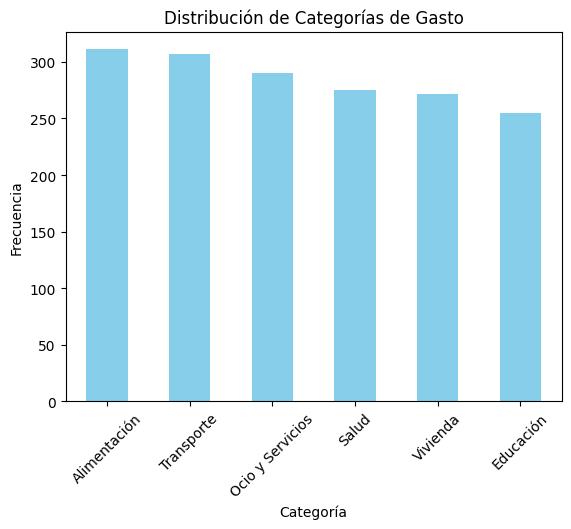

<Figure size 800x500 with 0 Axes>

In [7]:
fig = df_gastos["categoria"].value_counts().plot(kind="bar", color="skyblue")

fig.set_title("Distribución de Categorías de Gasto")
fig.set_xlabel("Categoría")
fig.set_ylabel("Frecuencia")
fig.tick_params(axis="x", rotation=45)

plt.figure(figsize=(8, 5))
plt.tight_layout()
plt.show()

#### Gráfico 2: Boxplot de montos por categoría


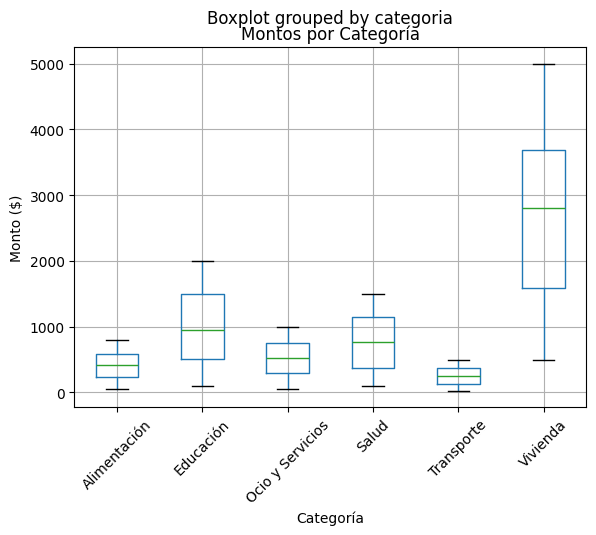

<Figure size 800x500 with 0 Axes>

In [8]:
fig = df_gastos.boxplot(column="monto", by="categoria")

fig.set_title("Montos por Categoría")
fig.set_xlabel("Categoría")
fig.set_ylabel("Monto ($)")
fig.tick_params(axis="x", rotation=45)

plt.figure(figsize=(8, 5))
plt.tight_layout()
plt.show()

# PROCESAMIENTO DE VARIABLES TEXTUALES


In [9]:
def limpiar_texto(texto):
    """Limpia y estandariza texto para NLP"""
    if pd.isna(texto):
        return ""

    # Convertir a minúsculas
    texto = str(texto).lower()

    # Eliminar acentos
    texto = (
        unicodedata.normalize("NFKD", texto).encode("ASCII", "ignore").decode("utf-8")
    )

    # Eliminar caracteres especiales y puntuación
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)

    # Eliminar espacios múltiples
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto


# Crea una lista simple con las stop words en español más comunes
stop_words_es = [
    "de",
    "la",
    "que",
    "el",
    "en",
    "y",
    "a",
    "los",
    "del",
    "se",
    "las",
    "por",
    "un",
    "para",
    "con",
    "no",
    "una",
    "su",
    "al",
    "lo",
    "como",
    "pero",
    "sus",
    "o",
    "este",
    "esta",
    "entre",
    "cuando",
    "sin",
    "sobre",
    "tambien",
    "me",
    "hasta",
    "hay",
    "donde",
    "desde",
    "todo",
    "nos",
    "durante",
    "todos",
    "uno",
    "les",
    "ni",
    "contra",
    "otros",
    "ese",
    "eso",
    "ante",
    "ellos",
    "esto",
]

In [10]:
def procesar_variables_textuales(df_gastos):
    """Procesa las variables textuales con TF-IDF"""
    print("\n" + "=" * 60)
    print("PROCESAMIENTO DE VARIABLES TEXTUALES")
    print("=" * 60)

    # Limpiar texto
    df_gastos["descripcion_limpia"] = df_gastos["descripcion"].apply(limpiar_texto)

    print("\nEjemplos de texto limpio:")
    for i in range(5):
        print(f"Original: {df_gastos.iloc[i]['descripcion']}")
        print(f"Limpio:   {df_gastos.iloc[i]['descripcion_limpia']}")
        print()

    # Vectorización TF-IDF
    vectorizer = TfidfVectorizer(max_features=600, stop_words=stop_words_es, ngram_range=(1, 2))

    # Separar características y etiquetas
    X = df_gastos["descripcion_limpia"]
    y = df_gastos["categoria"]

    # Transformar texto a vectores
    X_tfidf = vectorizer.fit_transform(X)

    print(f"\nDimensiones de la matriz TF-IDF: {X_tfidf.shape}")
    print(f"Número de características: {len(vectorizer.get_feature_names_out())}")

    # Mostrar características más importantes
    feature_names = vectorizer.get_feature_names_out()
    print("\nTop 10 características TF-IDF:")
    for i in range(10):
        print(f"  {i+1}. {feature_names[i]}")

    return vectorizer, X_tfidf, df_gastos

vectorizer, X_tfidf, df_gastos = procesar_variables_textuales(df_gastos)


PROCESAMIENTO DE VARIABLES TEXTUALES

Ejemplos de texto limpio:
Original: *supermercado*
Limpio:   supermercado

Original: COMPRA EN SUPERMERCADO
Limpio:   compra en supermercado

Original: *supermercado*
Limpio:   supermercado

Original: *supermercado*
Limpio:   supermercado

Original: COMPRA EN SUPERMERCADO
Limpio:   compra en supermercado


Dimensiones de la matriz TF-IDF: (1710, 600)
Número de características: 600

Top 10 características TF-IDF:
  1. abarrotes
  2. actividades
  3. administracion
  4. administracion condominios
  5. ado
  6. aeromexico
  7. agua
  8. ahorro
  9. alineacion
  10. alineacion balanceo


In [11]:
df_gastos

,descripcion,categoria,monto,descripcion_limpia
0,*supermercado*,Alimentación,647.41,supermercado
1,COMPRA EN SUPERMERCADO,Alimentación,498.99,compra en supermercado
2,*supermercado*,Alimentación,384.37,supermercado
3,*supermercado*,Alimentación,93.56,supermercado
4,COMPRA EN SUPERMERCADO,Alimentación,300.28,compra en supermercado
...,...,...,...,...
1705,DOMESTIKA,Educación,1995.49,domestika
1706,compra dermatologo,Salud,1445.62,compra dermatologo
1707,FARMACIAS DEL AHORRO,Salud,668.42,farmacias del ahorro
1708,Zoologico,Ocio y Servicios,270.42,zoologico


# Guarda el `CSV` procesado

In [12]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "transacciones_procesadas.csv"

df_gastos.to_csv(output_path, sep=",", encoding="utf-8", index=False)